# 02 — Entraînement v3 — Classification Bois / Taille Douce

**Projet** : Gallica Images — Illustrations des *Métamorphoses* d'Ovide  
**Date**   : Mai 2026

## Nouveautés par rapport à v1/v2
- Dataset enrichi — toutes les nouvelles éditions (29 dossiers, ~2150 illustrations)
- Pas de flip horizontal
- Illustrations telles quelles — couleurs naturelles conservées
- Class weights pour compenser le déséquilibre bois/cuivre (1:3.7)
- Early stopping — sauvegarde du meilleur epoch
- Courbes loss/accuracy train et val
- Nomenclature : `resnet50_bois_cuivre_v3.0.0.pth`

---

## 1. Configuration

In [1]:
import os, sys, shutil, random, json
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

RACINE          = os.path.abspath("../../../")
DOSSIER_SEG     = os.path.join(RACINE, "data", "segmentees")
DOSSIER_DATASET = os.path.join(RACINE, "data", "datasets", "bois_cuivre")
DOSSIER_MODELES = os.path.join(RACINE, "modeles", "bois_cuivre")
DOSSIER_EVAL    = os.path.join(RACINE, "resultats", "evaluation_modeles", "bois_cuivre")

VERSION = "v3.0.0"
NOM_MODELE = f"resnet50_bois_cuivre_{VERSION}.pth"

os.makedirs(DOSSIER_DATASET, exist_ok=True)
os.makedirs(DOSSIER_MODELES, exist_ok=True)
os.makedirs(DOSSIER_EVAL,    exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Racine  : {RACINE}")
print(f"Device  : {device}")
print(f"Version : {VERSION}")

Racine  : /mnt/c/Users/a.saidi/OneDrive - BNU/Bureau/working_dir
Device  : cuda
Version : v3.0.0


## 2. Sources du dataset

In [2]:
SOURCES = {
    "bois" : [
        "bois_eskrich_rouille_lyon1556",
        "bois_leroy_gueynard_lyon1510",
        "bois_salomon_rouille_lyon1557",
        "bois_solis_feyerabend_francfort1581",
        "bois_wickram_behem_mayence1545",
    ],
    "cuivre" : [
        "cuivre_baur_sn_augsbourg1709",
        "cuivre_baur_sn_vienne1639",
        "cuivre_blanchin_berthelin_rouen1651",
        "cuivre_borcht_plantin_anvers1591",
        "cuivre_bouche_blaeu_amsterdam1702",
        "cuivre_briot_drobet_lyon1628",
        "cuivre_depasse_depasse_koln1602",
        "cuivre_depasse_jansonius_arnhem1607",
        "cuivre_franco_giunta_venise1584",
        "cuivre_gaultier_guillemot_paris1610",
        "cuivre_gaultier_sn_paris1616",
        "cuivre_gaultier_veuveguillemot_paris1614",
        "cuivre_goltzius_goltzius_haarlem1589",
        "cuivre_ht_molin_lyon1697_t4",
        "cuivre_ht_molin_lyon1697_t5",
        "cuivre_ht_molin_lyon1697_t6",
        "cuivre_isaac_langelier_paris1617",
        "cuivre_mathieu_langelier_paris1619",
        "cuivre_monconet_sommaville_paris1660",
        "cuivre_philippe_hackiana_leyde1670",
        "cuivre_savery_farnaby_paris1637",
        "cuivre_tempesta_dejode_anvers1606",
        "cuivre_tempesta_jansonius_amsterdam1610",
        "cuivre_weyen_barbin_paris1669",
    ]
}

print("Sources du dataset v3 :\n")
for classe, dossiers in SOURCES.items():
    total = sum(
        len([f for f in os.listdir(os.path.join(DOSSIER_SEG, d)) if f.endswith(".jpg")])
        for d in dossiers if os.path.exists(os.path.join(DOSSIER_SEG, d))
    )
    print(f"  {classe:10s} : {len(dossiers)} éditions — {total} illustrations")

Sources du dataset v3 :

ERROR! Session/line number was not unique in database. History logging moved to new session 82
  bois       : 5 éditions — 456 illustrations
  cuivre     : 24 éditions — 1649 illustrations


## 3. Construction du dataset — split train/val/test

In [3]:
random.seed(42)

# Nettoyer les splits existants
for split in ["train", "val", "test"]:
    chemin = os.path.join(DOSSIER_DATASET, split)
    if os.path.exists(chemin):
        shutil.rmtree(chemin)

# Créer la structure
for split in ["train", "val", "test"]:
    for classe in ["bois", "cuivre"]:
        os.makedirs(os.path.join(DOSSIER_DATASET, split, classe), exist_ok=True)

RATIO_TRAIN = 0.70
RATIO_VAL   = 0.15

stats = {"train": {"bois": 0, "cuivre": 0},
         "val"  : {"bois": 0, "cuivre": 0},
         "test" : {"bois": 0, "cuivre": 0}}

for classe, dossiers in SOURCES.items():
    images = []
    for dossier in dossiers:
        chemin = os.path.join(DOSSIER_SEG, dossier)
        if not os.path.exists(chemin):
            continue
        for f in os.listdir(chemin):
            if f.endswith(".jpg"):
                images.append(os.path.join(chemin, f))

    random.shuffle(images)
    n       = len(images)
    n_train = int(n * RATIO_TRAIN)
    n_val   = int(n * RATIO_VAL)

    splits = {
        "train": images[:n_train],
        "val"  : images[n_train:n_train + n_val],
        "test" : images[n_train + n_val:]
    }

    for split, fichiers in splits.items():
        for src in fichiers:
            nom = f"{os.path.basename(os.path.dirname(src))}_{os.path.basename(src)}"
            dst = os.path.join(DOSSIER_DATASET, split, classe, nom)
            shutil.copy(src, dst)
            stats[split][classe] += 1

print("Dataset v3 construit :\n")
print(f"  {'Split':8s} {'Bois':>8} {'Cuivre':>8} {'Total':>8}")
print("  " + "─" * 30)
for split in ["train", "val", "test"]:
    b = stats[split]["bois"]
    c = stats[split]["cuivre"]
    print(f"  {split:8s} {b:>8} {c:>8} {b+c:>8}")

Dataset v3 construit :

  Split        Bois   Cuivre    Total
  ──────────────────────────────
  train         319     1154     1473
  val            68      247      315
  test           69      248      317


## 4. DataLoaders et transforms

In [4]:
# Transforms — pas de grayscale, pas de flip, illustrations telles quelles
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

dataset_train = datasets.ImageFolder(os.path.join(DOSSIER_DATASET, "train"), transform_train)
dataset_val   = datasets.ImageFolder(os.path.join(DOSSIER_DATASET, "val"),   transform_val)
dataset_test  = datasets.ImageFolder(os.path.join(DOSSIER_DATASET, "test"),  transform_val)

loader_train = DataLoader(dataset_train, batch_size=32, shuffle=True,  num_workers=0)
loader_val   = DataLoader(dataset_val,   batch_size=32, shuffle=False, num_workers=0)
loader_test  = DataLoader(dataset_test,  batch_size=32, shuffle=False, num_workers=0)

CLASSES = dataset_train.classes
print(f"Classes : {CLASSES}")
print(f"Train   : {len(dataset_train)} images")
print(f"Val     : {len(dataset_val)} images")
print(f"Test    : {len(dataset_test)} images")

Classes : ['bois', 'cuivre']
Train   : 1473 images
Val     : 315 images
Test    : 317 images


## 5. Class weights — compensation du déséquilibre

In [5]:
# Compter les exemples par classe dans le train
counts = np.bincount(dataset_train.targets)
total  = len(dataset_train)

class_weights = torch.tensor(
    [total / (len(CLASSES) * c) for c in counts],
    dtype=torch.float
).to(device)

print("Class weights :")
for i, (cls, w) in enumerate(zip(CLASSES, class_weights)):
    print(f"  {cls:10s} : {counts[i]:>5} exemples → weight {w:.4f}")

Class weights :
  bois       :   319 exemples → weight 2.3088
  cuivre     :  1154 exemples → weight 0.6382


## 6. Modèle — ResNet50 fine-tuning deux étapes

In [6]:
modele = models.resnet50(weights="IMAGENET1K_V1")

# Geler toutes les couches
for param in modele.parameters():
    param.requires_grad = False

# Remplacer la couche finale
modele.fc = nn.Linear(modele.fc.in_features, len(CLASSES))
modele     = modele.to(device)

print(f"✓ ResNet50 chargé — {len(CLASSES)} classes")
print(f"  Couches gelées — seule la couche finale est entraînable")

✓ ResNet50 chargé — 2 classes
  Couches gelées — seule la couche finale est entraînable


## 7. Fonctions d'entraînement

In [7]:
def train_epoch(modele, loader, criterion, optimizer):
    modele.train()
    total_loss = total_correct = total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = modele(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss    += loss.item() * images.size(0)
        total_correct += (outputs.argmax(1) == labels).sum().item()
        total         += images.size(0)
    return total_loss / total, total_correct / total


def eval_epoch(modele, loader, criterion):
    modele.eval()
    total_loss = total_correct = total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = modele(images)
            loss           = criterion(outputs, labels)
            total_loss    += loss.item() * images.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()
            total         += images.size(0)
    return total_loss / total, total_correct / total


def entrainer(modele, loader_train, loader_val, criterion, optimizer,
              n_epochs, patience=5, nom_modele="modele.pth"):
    historique = {"train_loss": [], "train_acc": [],
                  "val_loss"  : [], "val_acc"  : []}
    meilleur_val_loss = float("inf")
    patience_compteur = 0
    meilleur_epoch    = 0

    for epoch in range(1, n_epochs + 1):
        train_loss, train_acc = train_epoch(modele, loader_train, criterion, optimizer)
        val_loss,   val_acc   = eval_epoch(modele,  loader_val,   criterion)

        historique["train_loss"].append(train_loss)
        historique["train_acc"] .append(train_acc)
        historique["val_loss"]  .append(val_loss)
        historique["val_acc"]   .append(val_acc)

        print(f"  Epoch {epoch:>3}/{n_epochs} "
              f"| train loss {train_loss:.4f} acc {train_acc:.4f} "
              f"| val loss {val_loss:.4f} acc {val_acc:.4f}", end="")

        # Sauvegarder le meilleur modèle
        if val_loss < meilleur_val_loss:
            meilleur_val_loss = val_loss
            meilleur_epoch    = epoch
            patience_compteur = 0
            torch.save(modele.state_dict(),
                       os.path.join(DOSSIER_MODELES, nom_modele))
            print(" ← meilleur")
        else:
            patience_compteur += 1
            print(f" (patience {patience_compteur}/{patience})")
            if patience_compteur >= patience:
                print(f"\n  Early stopping — meilleur epoch : {meilleur_epoch}")
                break

    return historique, meilleur_epoch

print("✓ Fonctions d'entraînement définies")

✓ Fonctions d'entraînement définies


## 8. Étape 1 — Entraînement couche finale (10 epochs)

In [8]:
criterion  = nn.CrossEntropyLoss(weight=class_weights)
optimizer1 = optim.Adam(modele.fc.parameters(), lr=1e-3)

print("Étape 1 — couche finale uniquement\n")
hist1, best1 = entrainer(
    modele, loader_train, loader_val,
    criterion, optimizer1,
    n_epochs=10, patience=5,
    nom_modele=NOM_MODELE
)
print(f"\n✓ Étape 1 terminée — meilleur epoch : {best1}")

Étape 1 — couche finale uniquement

  Epoch   1/10 | train loss 0.2687 acc 0.9206 | val loss 0.1616 acc 0.9524 ← meilleur
  Epoch   2/10 | train loss 0.0926 acc 0.9864 | val loss 0.0732 acc 0.9810 ← meilleur
  Epoch   3/10 | train loss 0.0726 acc 0.9844 | val loss 0.0618 acc 0.9873 ← meilleur
  Epoch   4/10 | train loss 0.1304 acc 0.9369 | val loss 0.0468 acc 0.9810 ← meilleur
  Epoch   5/10 | train loss 0.0568 acc 0.9851 | val loss 0.0469 acc 0.9873 (patience 1/5)
  Epoch   6/10 | train loss 0.0446 acc 0.9905 | val loss 0.0436 acc 0.9873 ← meilleur
  Epoch   7/10 | train loss 0.1167 acc 0.9464 | val loss 0.0352 acc 0.9905 ← meilleur
  Epoch   8/10 | train loss 0.0354 acc 0.9939 | val loss 0.0381 acc 0.9873 (patience 1/5)
  Epoch   9/10 | train loss 0.0374 acc 0.9905 | val loss 0.0574 acc 0.9746 (patience 2/5)
  Epoch  10/10 | train loss 0.1097 acc 0.9457 | val loss 0.0455 acc 0.9778 (patience 3/5)

✓ Étape 1 terminée — meilleur epoch : 7


## 9. Étape 2 — Fine-tuning complet (30 epochs)

In [10]:
# Charger le meilleur modèle de l'étape 1
modele.load_state_dict(torch.load(
    os.path.join(DOSSIER_MODELES, NOM_MODELE), map_location=device
))

# Dégeler toutes les couches
for param in modele.parameters():
    param.requires_grad = True

# Learning rate plus faible pour le fine-tuning complet
optimizer2 = optim.Adam(modele.parameters(), lr=1e-4)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer2, mode="min", patience=3, factor=0.5
)

print("Étape 2 — fine-tuning complet\n")
hist2, best2 = entrainer(
    modele, loader_train, loader_val,
    criterion, optimizer2,
    n_epochs=30, patience=7,
    nom_modele=NOM_MODELE
)
print(f"\n✓ Étape 2 terminée — meilleur epoch : {best2}")

Étape 2 — fine-tuning complet

  Epoch   1/30 | train loss 0.0460 acc 0.9783 | val loss 0.0139 acc 0.9937 ← meilleur
  Epoch   2/30 | train loss 0.0109 acc 0.9973 | val loss 0.0008 acc 1.0000 ← meilleur
  Epoch   3/30 | train loss 0.0015 acc 1.0000 | val loss 0.0002 acc 1.0000 ← meilleur
  Epoch   4/30 | train loss 0.0123 acc 0.9946 | val loss 0.0227 acc 0.9937 (patience 1/7)
  Epoch   5/30 | train loss 0.0028 acc 0.9993 | val loss 0.0029 acc 1.0000 (patience 2/7)
  Epoch   6/30 | train loss 0.0100 acc 0.9959 | val loss 0.0012 acc 1.0000 (patience 3/7)
  Epoch   7/30 | train loss 0.0153 acc 0.9939 | val loss 0.0181 acc 0.9968 (patience 4/7)
  Epoch   8/30 | train loss 0.0119 acc 0.9959 | val loss 0.0020 acc 1.0000 (patience 5/7)
  Epoch   9/30 | train loss 0.0075 acc 0.9973 | val loss 0.0028 acc 1.0000 (patience 6/7)
  Epoch  10/30 | train loss 0.0037 acc 0.9986 | val loss 0.0038 acc 0.9968 (patience 7/7)

  Early stopping — meilleur epoch : 3

✓ Étape 2 terminée — meilleur epoch : 3


## 10. Courbes loss et accuracy

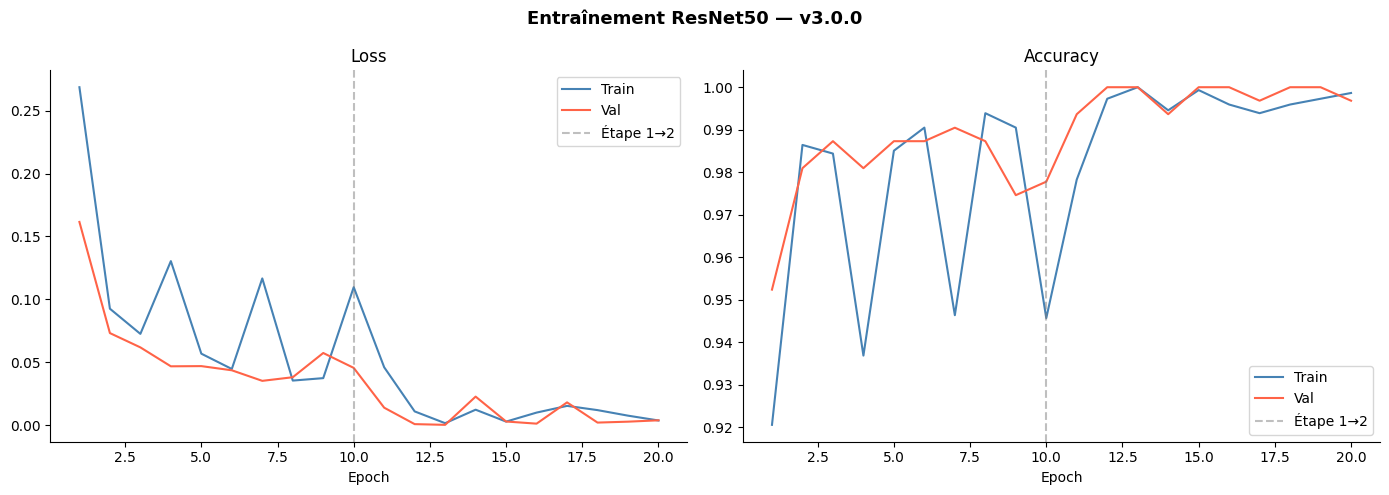

✓ Courbes sauvegardées


In [11]:
# Combiner les deux étapes
hist_total = {
    k: hist1[k] + hist2[k] for k in hist1
}
separation = len(hist1["train_loss"])  # ligne de séparation étape 1/2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Entraînement ResNet50 — {VERSION}",
             fontsize=13, fontweight="bold")

epochs = range(1, len(hist_total["train_loss"]) + 1)

# Loss
axes[0].plot(epochs, hist_total["train_loss"], label="Train", color="steelblue")
axes[0].plot(epochs, hist_total["val_loss"],   label="Val",   color="tomato")
axes[0].axvline(x=separation, color="gray", linestyle="--", alpha=0.5, label="Étape 1→2")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Accuracy
axes[1].plot(epochs, hist_total["train_acc"], label="Train", color="steelblue")
axes[1].plot(epochs, hist_total["val_acc"],   label="Val",   color="tomato")
axes[1].axvline(x=separation, color="gray", linestyle="--", alpha=0.5, label="Étape 1→2")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(DOSSIER_EVAL, f"courbes_{VERSION}.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Courbes sauvegardées")

## 11. Évaluation finale sur le test set

Rapport de classification :

              precision    recall  f1-score   support

        bois     1.0000    1.0000    1.0000        69
      cuivre     1.0000    1.0000    1.0000       248

    accuracy                         1.0000       317
   macro avg     1.0000    1.0000    1.0000       317
weighted avg     1.0000    1.0000    1.0000       317



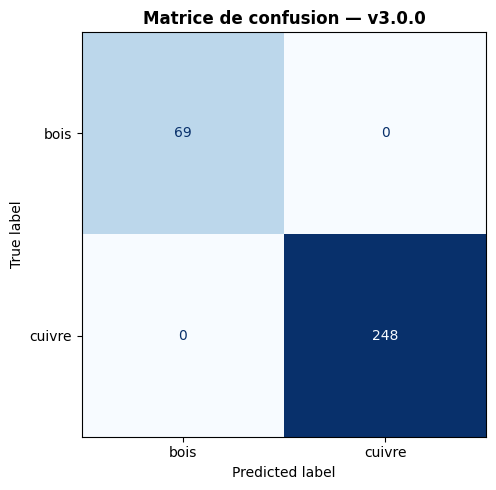

✓ Matrice sauvegardée
✓ Historique sauvegardé


In [12]:
# Charger le meilleur modèle
modele.load_state_dict(torch.load(
    os.path.join(DOSSIER_MODELES, NOM_MODELE), map_location=device
))
modele.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in loader_test:
        images = images.to(device)
        preds  = modele(images).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("Rapport de classification :\n")
print(classification_report(all_labels, all_preds,
                             target_names=CLASSES, digits=4))

# Matrice de confusion
cm  = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Matrice de confusion — {VERSION}", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(DOSSIER_EVAL, f"matrice_confusion_{VERSION}.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Matrice sauvegardée")

# Sauvegarder l'historique
with open(os.path.join(DOSSIER_EVAL, f"historique_{VERSION}.json"), "w") as f:
    json.dump(hist_total, f, indent=2)
print(f"✓ Historique sauvegardé")

In [14]:
from PIL import Image

dossier_couleur = os.path.join(DOSSIER_SEG, "cuivre_goltzius_goltzius_haarlem1589_couleur")
images = [f for f in os.listdir(dossier_couleur) if f.endswith(".jpg")]

print(f"Goltzius couleur — {len(images)} images\n")

correct = 0
for img_nom in images:
    chemin_img = os.path.join(dossier_couleur, img_nom)
    img    = Image.open(chemin_img).convert("RGB")
    tensor = transform_val(img).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = modele(tensor).argmax(1).item()
    if CLASSES[pred] == "cuivre":
        correct += 1

print(f"  Accuracy v3 : {correct/len(images):.2f} ({correct}/{len(images)})")

Goltzius couleur — 38 images

  Accuracy v3 : 1.00 (38/38)


In [16]:
import os

DOSSIER_SEG = os.path.join(os.path.abspath("../../../"), "data", "segmentees")

total = 0
n_editions = 0

for dossier in sorted(os.listdir(DOSSIER_SEG)):
    chemin = os.path.join(DOSSIER_SEG, dossier)
    if not os.path.isdir(chemin) or "_flip" in dossier or "_couleur" in dossier:
        continue
    n = len([f for f in os.listdir(chemin) if f.endswith(".jpg")])
    total += n
    n_editions += 1

print(f"Éditions (dossiers)      : {n_editions}")
print(f"Illustrations segmentées : {total}")

Éditions (dossiers)      : 29
Illustrations segmentées : 2105
